## **Прогнозирование стоимости жилья в Калифорнии**
### Сравнение линейных моделей: OLS, Ridge, Lasso

**Данные:** California Housing dataset (sklearn)  
**Задача:** регрессия, предсказание MedHouseVal  
**Методы:** EDA, линейная регрессия, регуляризация, кросс-валидация, VIF-анализ мультиколлинеарности, диагностика остатков

#### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import scipy.stats as stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, GridSearchCV
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# Оформление вывода

def banner(title):
    width = 70
    print("\n" + "═" * width)
    print(f"  {title}")
    print("═" * width)

def section(title):
    print(f"\n{'─' * 60}")
    print(f"  ▶  {title}")
    print(f"{'─' * 60}")

def ok(msg):
    print(f"  ✔  {msg}")

def info(msg):
    print(f"     {msg}")

#### Загрузка и разведочный анализ данных

In [2]:
banner("ШАГ 1 / 7  —  ЗАГРУЗКА И РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ")

housing = fetch_california_housing(as_frame=True)
df = housing.frame

section("Общая информация о датасете")
ok(f"Датасет: California Housing  |  {df.shape[0]:,} наблюдений  |  {df.shape[1]} переменных")
info("")
info("Описание признаков:")
info("  MedInc       — медианный доход домохозяйств в округе (ед. $10 000)")
info("  HouseAge     — медианный возраст домов в округе (лет)")
info("  AveRooms     — среднее число комнат на домохозяйство")
info("  AveBedrms    — среднее число спален на домохозяйство")
info("  Population   — население округа")
info("  AveOccup     — среднее число жильцов на домохозяйство")
info("  Latitude     — широта")
info("  Longitude    — долгота")
info("  MedHouseVal  — ЦЕЛЕВАЯ: медианная стоимость жилья (ед. $100 000)")


══════════════════════════════════════════════════════════════════════
  ШАГ 1 / 7  —  ЗАГРУЗКА И РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Общая информация о датасете
────────────────────────────────────────────────────────────
  ✔  Датасет: California Housing  |  20,640 наблюдений  |  9 переменных
     
     Описание признаков:
       MedInc       — медианный доход домохозяйств в округе (ед. $10 000)
       HouseAge     — медианный возраст домов в округе (лет)
       AveRooms     — среднее число комнат на домохозяйство
       AveBedrms    — среднее число спален на домохозяйство
       Population   — население округа
       AveOccup     — среднее число жильцов на домохозяйство
       Latitude     — широта
       Longitude    — долгота
       MedHouseVal  — ЦЕЛЕВАЯ: медианная стоимость жилья (ед. $100 000)


In [29]:
section("Описательная статистика")
print(df.describe().round(3).to_string())

section("Проверка пропущенных значений")
missing = df.isnull().sum()
if missing.sum() == 0:
    ok("Пропущенные значения отсутствуют — предобработка не требуется")
else:
    print(missing[missing > 0])


────────────────────────────────────────────────────────────
  ▶  Описательная статистика
────────────────────────────────────────────────────────────
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup   Latitude  Longitude  MedHouseVal
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000  20640.000  20640.000    20640.000
mean       3.871     28.639      5.429      1.097    1425.477      3.071     35.632   -119.570        2.069
std        1.900     12.586      2.474      0.474    1132.462     10.386      2.136      2.004        1.154
min        0.500      1.000      0.846      0.333       3.000      0.692     32.540   -124.350        0.150
25%        2.563     18.000      4.441      1.006     787.000      2.430     33.930   -121.800        1.196
50%        3.535     29.000      5.229      1.049    1166.000      2.818     34.260   -118.490        1.797
75%        4.743     37.000      6.052      1.100    1725.000      3.282     37.710   -118.0

#### Визуализация: корреляции и распределения


══════════════════════════════════════════════════════════════════════
  ШАГ 2 / 7  —  ВИЗУАЛИЗАЦИЯ ДАННЫХ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Строим графики...
────────────────────────────────────────────────────────────
  ✔  График сохранён: 01_exploratory_analysis.png


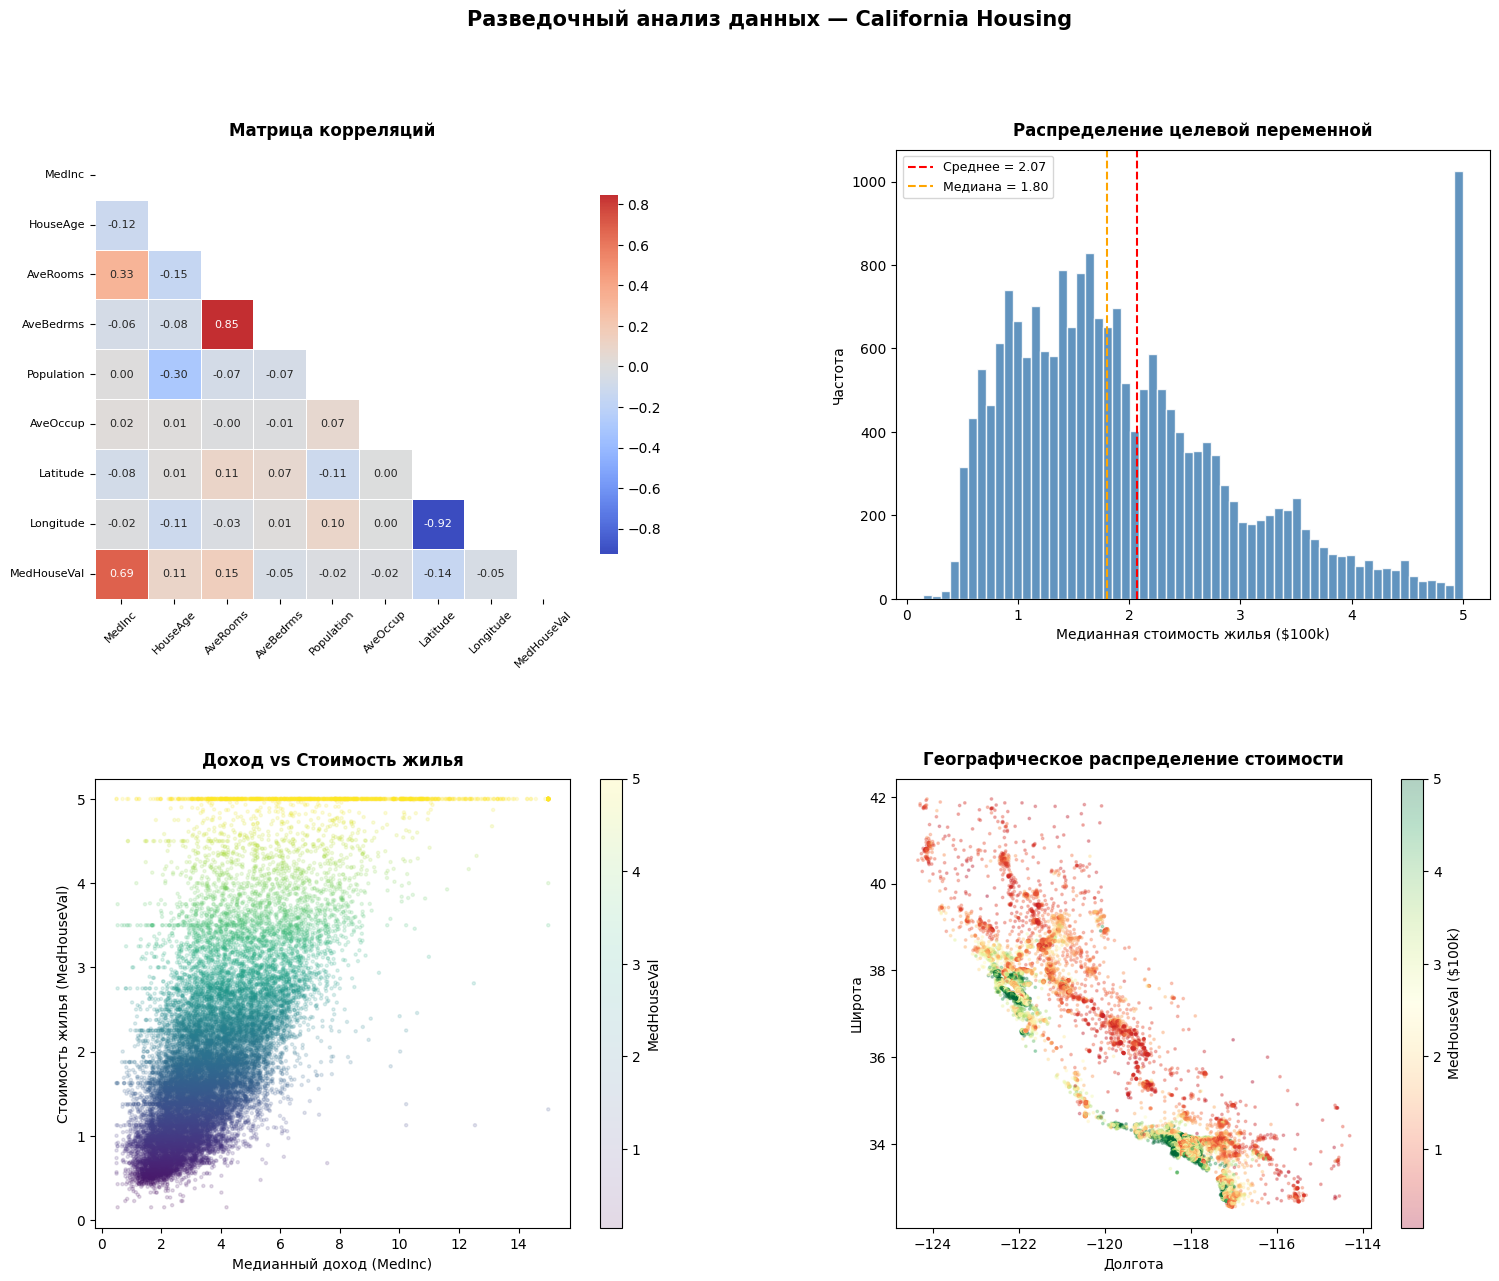

In [30]:
banner("ШАГ 2 / 7  —  ВИЗУАЛИЗАЦИЯ ДАННЫХ")

section("Строим графики...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Разведочный анализ данных — California Housing",
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# 1. Тепловая карта корреляций
ax1 = fig.add_subplot(gs[0, 0])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax1, annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax1.set_title("Матрица корреляций", fontweight='bold', pad=10)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# 2. Распределение целевой переменной
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['MedHouseVal'], bins=60, color='steelblue',
         edgecolor='white', alpha=0.85)
ax2.axvline(df['MedHouseVal'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Среднее = {df['MedHouseVal'].mean():.2f}")
ax2.axvline(df['MedHouseVal'].median(), color='orange', linestyle='--',
            linewidth=1.5, label=f"Медиана = {df['MedHouseVal'].median():.2f}")
ax2.set_xlabel("Медианная стоимость жилья ($100k)")
ax2.set_ylabel("Частота")
ax2.set_title("Распределение целевой переменной", fontweight='bold', pad=10)
ax2.legend(fontsize=9)

# 3. Доход vs Стоимость (scatter)
ax3 = fig.add_subplot(gs[1, 0])
sc = ax3.scatter(df['MedInc'], df['MedHouseVal'],
                 alpha=0.15, s=5, c=df['MedHouseVal'],
                 cmap='viridis')
plt.colorbar(sc, ax=ax3, label='MedHouseVal')
ax3.set_xlabel("Медианный доход (MedInc)")
ax3.set_ylabel("Стоимость жилья (MedHouseVal)")
ax3.set_title("Доход vs Стоимость жилья", fontweight='bold', pad=10)

# 4. Географическое распределение
ax4 = fig.add_subplot(gs[1, 1])
sc2 = ax4.scatter(df['Longitude'], df['Latitude'],
                  c=df['MedHouseVal'], cmap='RdYlGn',
                  alpha=0.3, s=3)
plt.colorbar(sc2, ax=ax4, label='MedHouseVal ($100k)')
ax4.set_xlabel("Долгота")
ax4.set_ylabel("Широта")
ax4.set_title("Географическое распределение стоимости", fontweight='bold', pad=10)

plt.savefig("01_exploratory_analysis.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 01_exploratory_analysis.png")
plt.show()

#### Подготовка данных

In [32]:
banner("ШАГ 3 / 7  —  ПОДГОТОВКА ДАННЫХ")

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

section("Разбивка на выборки")
ok(f"Обучающая выборка:  {X_train.shape[0]:,} наблюдений  ({100*len(X_train)/len(X):.0f}%)")
ok(f"Тестовая выборка:   {X_test.shape[0]:,} наблюдений  ({100*len(X_test)/len(X):.0f}%)")
ok("Стандартизация выполнена")


══════════════════════════════════════════════════════════════════════
  ШАГ 3 / 7  —  ПОДГОТОВКА ДАННЫХ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Разбивка на выборки
────────────────────────────────────────────────────────────
  ✔  Обучающая выборка:  16,512 наблюдений  (80%)
  ✔  Тестовая выборка:   4,128 наблюдений  (20%)
  ✔  Стандартизация выполнена


#### Разведочный анализ (EDA)

#### OLS-регрессия (Scikit-learn)

In [33]:
banner("ШАГ 4 / 7  —  OLS-РЕГРЕССИЯ (МНК)")

section("Результаты модели — Scikit-learn")
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

ok(f"R²   = {r2_lr:.4f}")
ok(f"RMSE = {rmse_lr:.4f}  (ед. $100 000)")
ok(f"MAE  = {mae_lr:.4f}  (ед. $100 000)")

section("Коэффициенты модели OLS")
coef_sr = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(f"\n  {'Признак':<15} {'Коэффициент':>14}")
print(f"  {'─'*15} {'─'*14}")
print(f"  {'Intercept':<15} {lr.intercept_:>14.4f}")
for feat, val in coef_sr.items():
    print(f"  {feat:<15} {val:>14.4f}")


══════════════════════════════════════════════════════════════════════
  ШАГ 4 / 7  —  OLS-РЕГРЕССИЯ (МНК)
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Результаты модели — Scikit-learn
────────────────────────────────────────────────────────────
  ✔  R²   = 0.5758
  ✔  RMSE = 0.7456  (ед. $100 000)
  ✔  MAE  = 0.5332  (ед. $100 000)

────────────────────────────────────────────────────────────
  ▶  Коэффициенты модели OLS
────────────────────────────────────────────────────────────

  Признак            Коэффициент
  ─────────────── ──────────────
  Intercept               2.0719
  Latitude               -0.8969
  Longitude              -0.8698
  MedInc                  0.8544
  AveBedrms               0.3393
  AveRooms               -0.2944
  HouseAge                0.1225
  AveOccup               -0.0408
  Population             -0.0023


#### Подготовка данных и масштабирование

#### (продолжение). Statsmodels OLS

In [34]:
section("Полная статистическая таблица — Statsmodels OLS")
X_train_sm = sm.add_constant(X_train_s)
ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())


────────────────────────────────────────────────────────────
  ▶  Полная статистическая таблица — Statsmodels OLS
────────────────────────────────────────────────────────────
                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:47:15   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err  

#### 10-кратная кросс-валидация

In [36]:
banner("ШАГ 5 / 7  —  10-КРАТНАЯ КРОСС-ВАЛИДАЦИЯ")

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_r2   = cross_val_score(lr, X_train_s, y_train, cv=kf, scoring='r2')
cv_rmse = cross_val_score(lr, X_train_s, y_train, cv=kf,
                          scoring='neg_root_mean_squared_error')

section("Результаты кросс-валидации")
print(f"\n  {'Фолд':<8} {'R²':>8} {'RMSE':>10}")
print(f"  {'─'*8} {'─'*8} {'─'*10}")
for i, (r2v, rmse_v) in enumerate(zip(cv_r2, -cv_rmse), 1):
    print(f"  {i:<8} {r2v:>8.4f} {rmse_v:>10.4f}")
print(f"  {'─'*8} {'─'*8} {'─'*10}")
print(f"  {'Среднее':<8} {cv_r2.mean():>8.4f} {(-cv_rmse).mean():>10.4f}")
print(f"  {'Std':<8} {cv_r2.std():>8.4f} {(-cv_rmse).std():>10.4f}")

ok(f"\nCV R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
ok(f"Test R² = {r2_lr:.4f}  →  модель обобщает {'хорошо ✔' if abs(cv_r2.mean() - r2_lr) < 0.03 else 'с отклонением ⚠'}")



══════════════════════════════════════════════════════════════════════
  ШАГ 5 / 7  —  10-КРАТНАЯ КРОСС-ВАЛИДАЦИЯ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Результаты кросс-валидации
────────────────────────────────────────────────────────────

  Фолд           R²       RMSE
  ──────── ──────── ──────────
  1          0.6041     0.7440
  2          0.6137     0.7250
  3          0.6299     0.6989
  4          0.5774     0.7518
  5          0.6199     0.7258
  6          0.6517     0.6678
  7          0.5878     0.7481
  8          0.6132     0.7185
  9          0.6204     0.7144
  10         0.5937     0.7107
  ──────── ──────── ──────────
  Среднее    0.6112     0.7205
  Std        0.0205     0.0239
  ✔  
CV R² = 0.6112 ± 0.0205
  ✔  Test R² = 0.5758  →  модель обобщает с отклонением ⚠


  ✔  График сохранён: 02_cross_validation.png


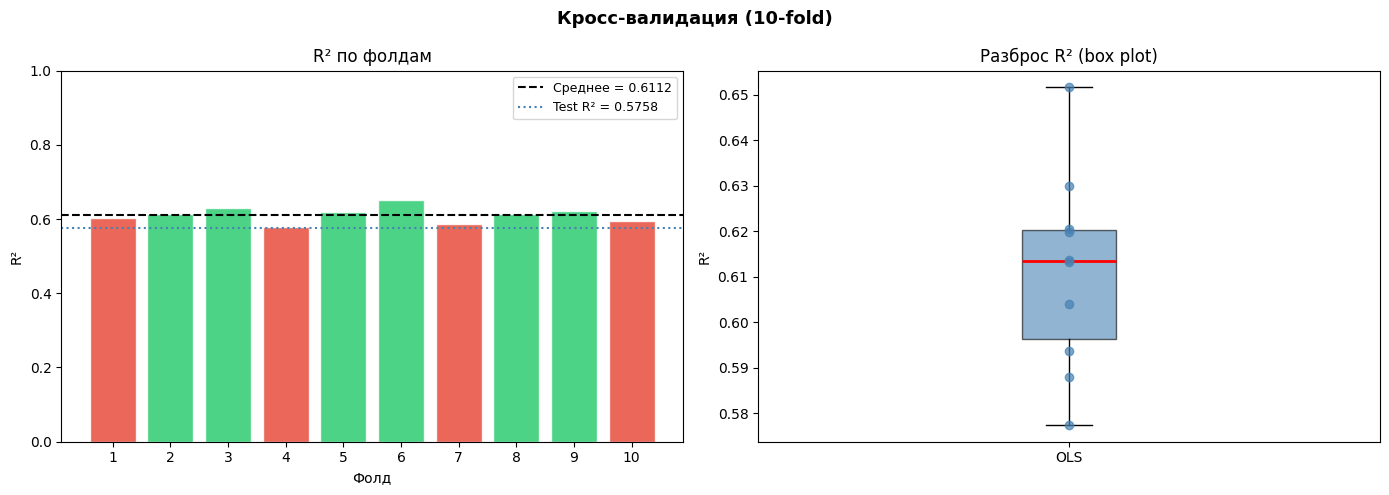

In [37]:
# График CV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Кросс-валидация (10-fold)", fontsize=13, fontweight='bold')

colors = ['#2ecc71' if v >= cv_r2.mean() else '#e74c3c' for v in cv_r2]
axes[0].bar(range(1, 11), cv_r2, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(cv_r2.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Среднее = {cv_r2.mean():.4f}')
axes[0].axhline(r2_lr, color='steelblue', linestyle=':', linewidth=1.5,
                label=f'Test R² = {r2_lr:.4f}')
axes[0].set_xlabel("Фолд")
axes[0].set_ylabel("R²")
axes[0].set_title("R² по фолдам")
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, 11))
axes[0].set_ylim(0, 1)

axes[1].boxplot(cv_r2, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].scatter([1]*10, cv_r2, color='steelblue', alpha=0.7, zorder=5)
axes[1].set_ylabel("R²")
axes[1].set_title("Разброс R² (box plot)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(['OLS'])

plt.tight_layout()
plt.savefig("02_cross_validation.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 02_cross_validation.png")
plt.show()

#### VIF (мультиколлинеарность)

In [38]:
banner("ШАГ 6 / 7  —  МУЛЬТИКОЛЛИНЕАРНОСТЬ И РЕГУЛЯРИЗАЦИЯ")

section("Диагностика мультиколлинеарности (VIF)")

vif_df = pd.DataFrame({
    'Признак': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i)
            for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(f"\n  {'Признак':<15} {'VIF':>8}  {'Статус':}")
print(f"  {'─'*15} {'─'*8}  {'─'*20}")
for _, row in vif_df.iterrows():
    v = row['VIF']
    if v < 5:
        status = "✔  норма"
    elif v < 10:
        status = "⚠  умеренная коллинеарность"
    else:
        status = "✘  высокая коллинеарность"
    print(f"  {row['Признак']:<15} {v:>8.2f}  {status}")


══════════════════════════════════════════════════════════════════════
  ШАГ 6 / 7  —  МУЛЬТИКОЛЛИНЕАРНОСТЬ И РЕГУЛЯРИЗАЦИЯ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Диагностика мультиколлинеарности (VIF)
────────────────────────────────────────────────────────────

  Признак              VIF  Статус
  ─────────────── ────────  ────────────────────
  Longitude         641.22  ✘  высокая коллинеарность
  Latitude          560.58  ✘  высокая коллинеарность
  AveBedrms          48.33  ✘  высокая коллинеарность
  AveRooms           46.79  ✘  высокая коллинеарность
  MedInc             11.83  ✘  высокая коллинеарность
  HouseAge            7.16  ⚠  умеренная коллинеарность
  Population          2.92  ✔  норма
  AveOccup            1.08  ✔  норма


#### Подбор alpha и обучение Ridge/Lasso/ElasticNet

In [39]:
section("Подбор оптимального α через GridSearchCV (10-fold CV)")

alphas = np.logspace(-3, 3, 60)

ridge_cv = GridSearchCV(Ridge(), {'alpha': alphas},
                        cv=10, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train_s, y_train)
best_a_ridge = ridge_cv.best_params_['alpha']

lasso_cv = GridSearchCV(Lasso(max_iter=20000), {'alpha': alphas},
                        cv=10, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train_s, y_train)
best_a_lasso = lasso_cv.best_params_['alpha']

enet_cv = GridSearchCV(
    ElasticNet(max_iter=20000),
    {'alpha': alphas, 'l1_ratio': [0.2, 0.5, 0.8]},
    cv=10, scoring='r2', n_jobs=-1
)
enet_cv.fit(X_train_s, y_train)
best_a_enet  = enet_cv.best_params_['alpha']
best_l1_enet = enet_cv.best_params_['l1_ratio']

ok(f"Ridge    — оптимальный α = {best_a_ridge:.4f}")
ok(f"Lasso    — оптимальный α = {best_a_lasso:.4f}")
ok(f"ElasticNet — α = {best_a_enet:.4f},  l1_ratio = {best_l1_enet:.2f}")

# Обучение финальных моделей
ridge = Ridge(alpha=best_a_ridge)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

lasso = Lasso(alpha=best_a_lasso, max_iter=20000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)

enet = ElasticNet(alpha=best_a_enet, l1_ratio=best_l1_enet, max_iter=20000)
enet.fit(X_train_s, y_train)
y_pred_enet = enet.predict(X_test_s)


────────────────────────────────────────────────────────────
  ▶  Подбор оптимального α через GridSearchCV (10-fold CV)
────────────────────────────────────────────────────────────
  ✔  Ridge    — оптимальный α = 1.4208
  ✔  Lasso    — оптимальный α = 0.0010
  ✔  ElasticNet — α = 0.0010,  l1_ratio = 0.80


#### Сравнение коэффициентов

In [48]:
section("Сравнение коэффициентов: OLS vs Ridge vs Lasso vs ElasticNet")

coef_table = pd.DataFrame({
    'OLS':        lr.coef_,
    'Ridge':      ridge.coef_,
    'Lasso':      lasso.coef_,
    'ElasticNet': enet.coef_,
}, index=X.columns)

print(f"\n  {'Признак':<15} {'OLS':>10} {'Ridge':>10} {'Lasso':>10} {'ElasticNet':>12}")
print(f"  {'─'*15} {'─'*10} {'─'*10} {'─'*10} {'─'*12}")
for feat, row in coef_table.iterrows():
    print(f"  {feat:<15} {row['OLS']:>10.4f} {row['Ridge']:>10.4f} {row['Lasso']:>10.4f} {row['ElasticNet']:>12.4f}")

# Проверка близости к нулю (а не строгого нуля)
near_zero = (abs(lasso.coef_) < 0.01).sum()
if near_zero:
    ok(f"{near_zero} признак(ов) имеют коэффициенты Lasso близкие к нулю (<0.01)")


────────────────────────────────────────────────────────────
  ▶  Сравнение коэффициентов: OLS vs Ridge vs Lasso vs ElasticNet
────────────────────────────────────────────────────────────

  Признак                OLS      Ridge      Lasso   ElasticNet
  ─────────────── ────────── ────────── ────────── ────────────
  MedInc              0.8544     0.8543     0.8491       0.8500
  HouseAge            0.1225     0.1227     0.1233       0.1234
  AveRooms           -0.2944    -0.2941    -0.2813      -0.2833
  AveBedrms           0.3393     0.3389     0.3260       0.3279
  Population         -0.0023    -0.0023    -0.0011      -0.0012
  AveOccup           -0.0408    -0.0408    -0.0399      -0.0401
  Latitude           -0.8969    -0.8958    -0.8858      -0.8855
  Longitude          -0.8698    -0.8687    -0.8581      -0.8579
  ✔  1 признак(ов) имеют коэффициенты Lasso близкие к нулю (<0.01)


#### Кривые регуляризации (графики)

  ✔  График сохранён: 03_regularization_paths.png


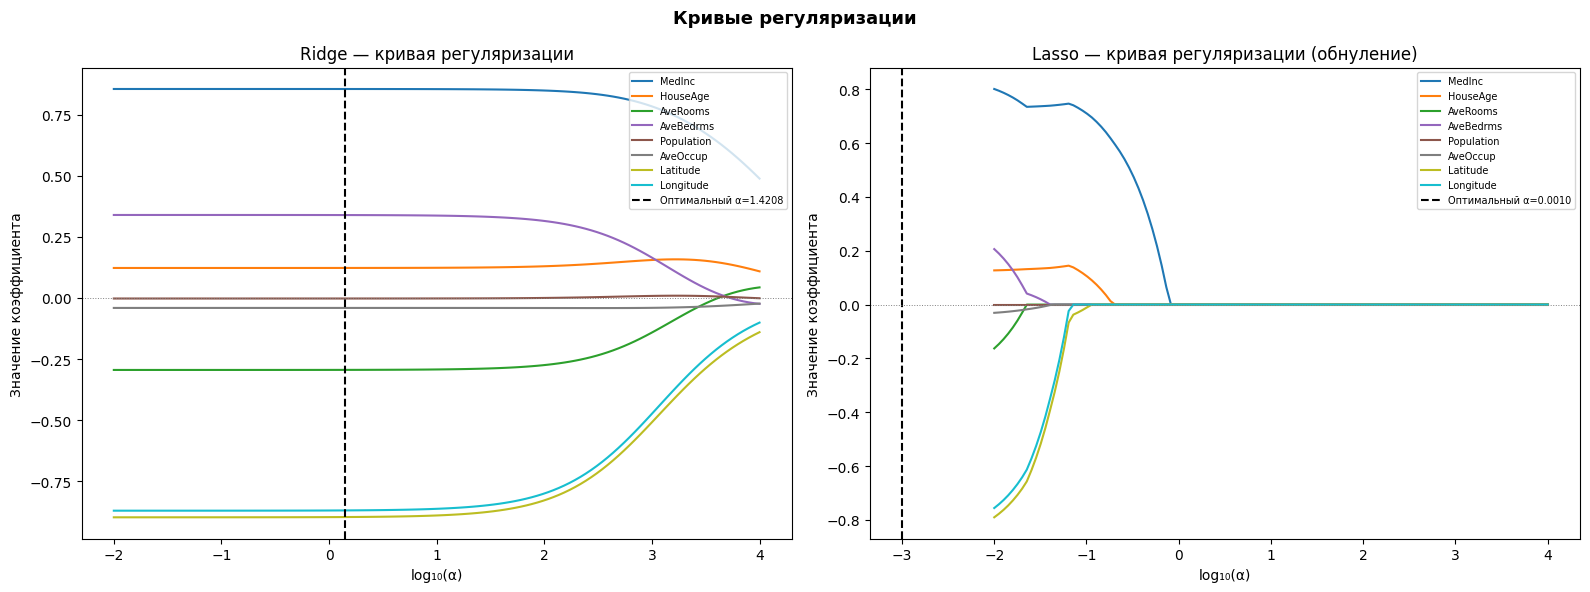

In [41]:
alphas_path = np.logspace(-2, 4, 120)
coefs_ridge = np.array([Ridge(alpha=a).fit(X_train_s, y_train).coef_
                        for a in alphas_path])
coefs_lasso = np.array([Lasso(alpha=a, max_iter=20000).fit(X_train_s, y_train).coef_
                        for a in alphas_path])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Кривые регуляризации", fontsize=13, fontweight='bold')

colors_path = plt.cm.tab10(np.linspace(0, 1, len(X.columns)))

for i, (col, c) in enumerate(zip(X.columns, colors_path)):
    axes[0].plot(np.log10(alphas_path), coefs_ridge[:, i], label=col, color=c, lw=1.5)
axes[0].axvline(np.log10(best_a_ridge), color='black', linestyle='--', lw=1.5,
                label=f'Оптимальный α={best_a_ridge:.4f}')
axes[0].set_xlabel("log₁₀(α)")
axes[0].set_ylabel("Значение коэффициента")
axes[0].set_title("Ridge — кривая регуляризации")
axes[0].legend(fontsize=7, loc='upper right')
axes[0].axhline(0, color='grey', linewidth=0.7, linestyle=':')

for i, (col, c) in enumerate(zip(X.columns, colors_path)):
    axes[1].plot(np.log10(alphas_path), coefs_lasso[:, i], label=col, color=c, lw=1.5)
axes[1].axvline(np.log10(best_a_lasso), color='black', linestyle='--', lw=1.5,
                label=f'Оптимальный α={best_a_lasso:.4f}')
axes[1].set_xlabel("log₁₀(α)")
axes[1].set_ylabel("Значение коэффициента")
axes[1].set_title("Lasso — кривая регуляризации (обнуление)")
axes[1].legend(fontsize=7, loc='upper right')
axes[1].axhline(0, color='grey', linewidth=0.7, linestyle=':')

plt.tight_layout()
plt.savefig("03_regularization_paths.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 03_regularization_paths.png")
plt.show()

#### Сравнение коэффициентов (bar chart)

  ✔  График сохранён: 04_coef_comparison.png


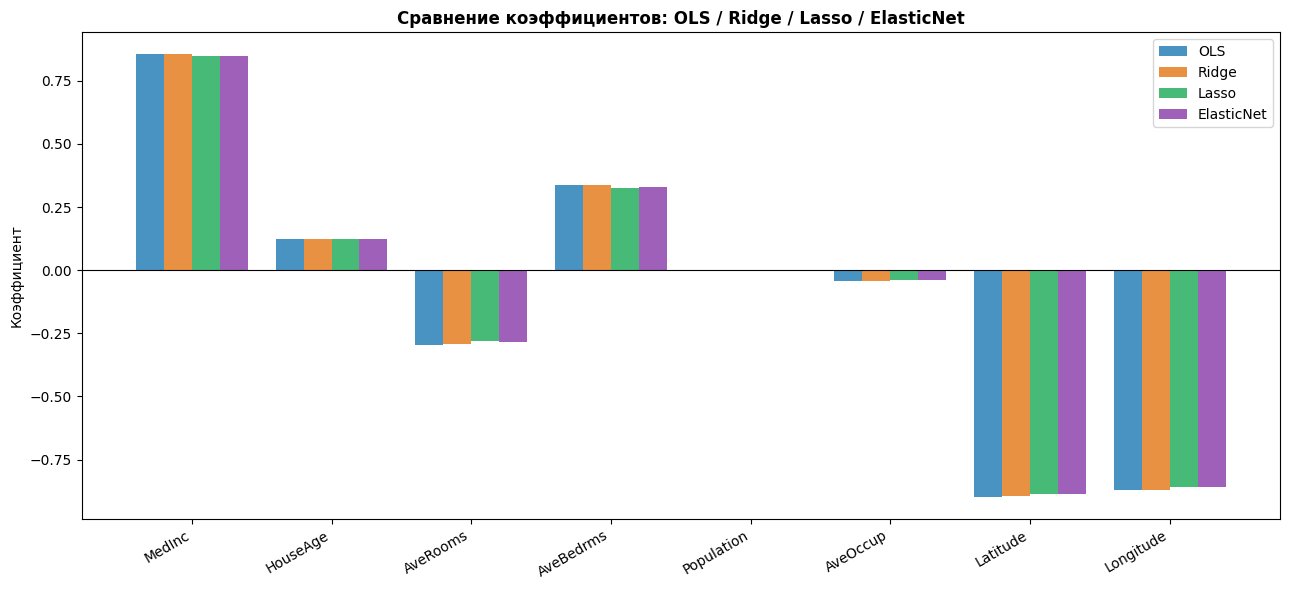

In [42]:
fig, ax = plt.subplots(figsize=(13, 6))
x    = np.arange(len(X.columns))
w    = 0.2
cols = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad']

ax.bar(x - 1.5*w, lr.coef_,    w, label='OLS',        color=cols[0], alpha=0.85)
ax.bar(x - 0.5*w, ridge.coef_, w, label='Ridge',      color=cols[1], alpha=0.85)
ax.bar(x + 0.5*w, lasso.coef_, w, label='Lasso',      color=cols[2], alpha=0.85)
ax.bar(x + 1.5*w, enet.coef_,  w, label='ElasticNet', color=cols[3], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(X.columns, rotation=30, ha='right', fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Коэффициент")
ax.set_title("Сравнение коэффициентов: OLS / Ridge / Lasso / ElasticNet",
             fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("04_coef_comparison.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 04_coef_comparison.png")
plt.show()

#### Диагностика остатков OLS


══════════════════════════════════════════════════════════════════════
  ШАГ 7 / 7  —  ДИАГНОСТИКА ОСТАТКОВ И ИТОГОВОЕ СРАВНЕНИЕ
══════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  ▶  Диагностические графики остатков (OLS)
────────────────────────────────────────────────────────────
  ✔  График сохранён: 05_residual_diagnostics.png


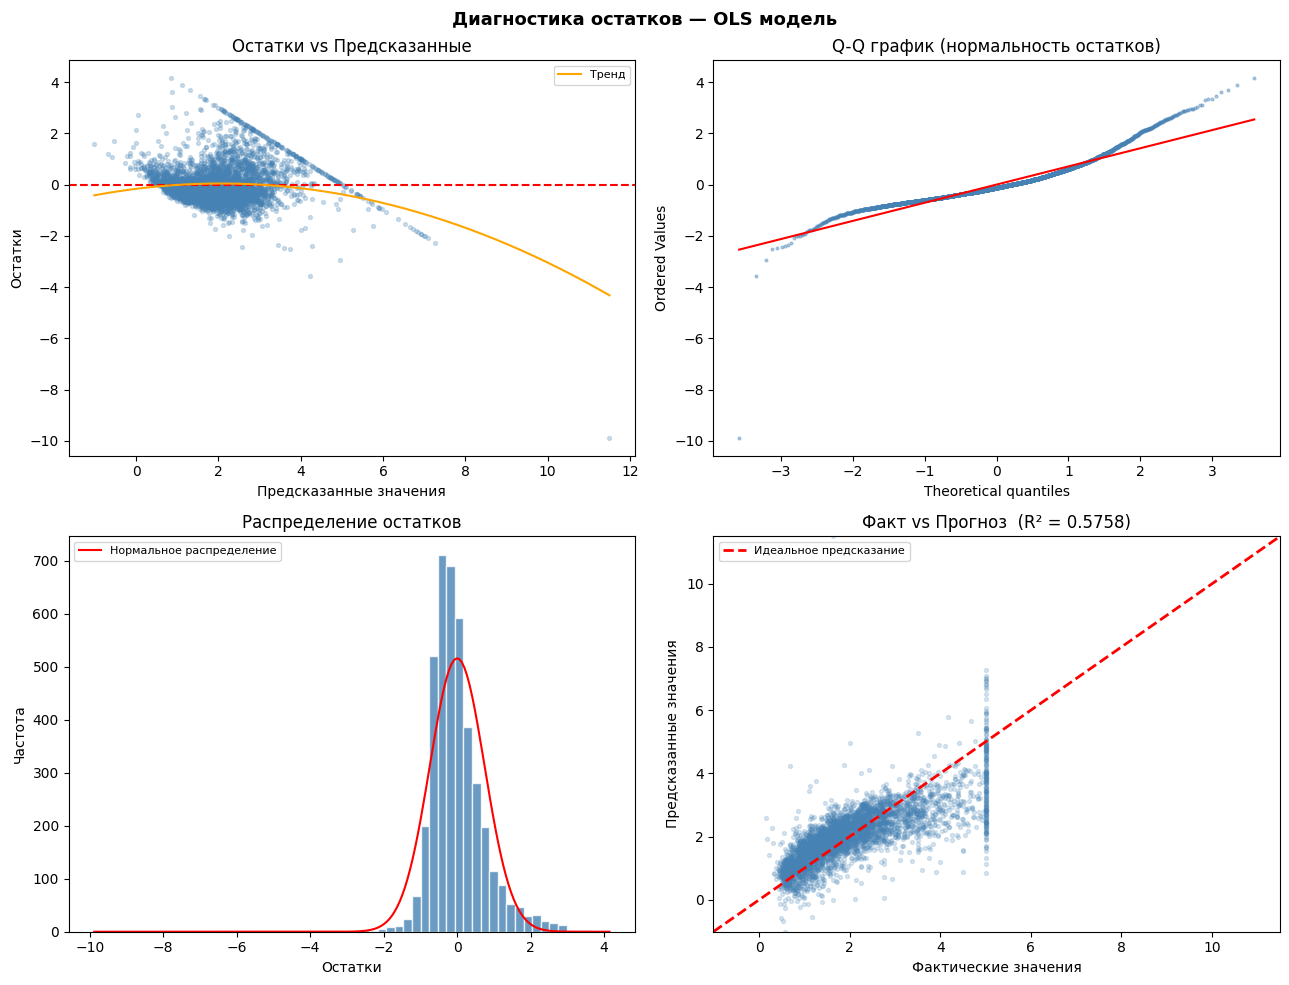

In [43]:
banner("ШАГ 7 / 7  —  ДИАГНОСТИКА ОСТАТКОВ И ИТОГОВОЕ СРАВНЕНИЕ")

section("Диагностические графики остатков (OLS)")

residuals = y_test.values - y_pred_lr
fitted    = y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Диагностика остатков — OLS модель", fontsize=13, fontweight='bold')

# 1. Остатки vs Предсказанные
axes[0,0].scatter(fitted, residuals, alpha=0.25, s=8, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', lw=1.5)
z = np.polyfit(fitted, residuals, 2)
xp = np.linspace(fitted.min(), fitted.max(), 200)
axes[0,0].plot(xp, np.polyval(z, xp), color='orange', lw=1.5, label='Тренд')
axes[0,0].set_xlabel("Предсказанные значения")
axes[0,0].set_ylabel("Остатки")
axes[0,0].set_title("Остатки vs Предсказанные")
axes[0,0].legend(fontsize=8)

# 2. Q-Q график
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q график (нормальность остатков)")
axes[0,1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')
axes[0,1].get_lines()[1].set(color='red', lw=1.5)

# 3. Гистограмма остатков
axes[1,0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
mu, std = residuals.mean(), residuals.std()
x_norm  = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,0].plot(x_norm,
               len(residuals) * (residuals.max()-residuals.min())/60
               * stats.norm.pdf(x_norm, mu, std),
               color='red', lw=1.5, label='Нормальное распределение')
axes[1,0].set_xlabel("Остатки")
axes[1,0].set_ylabel("Частота")
axes[1,0].set_title("Распределение остатков")
axes[1,0].legend(fontsize=8)

# 4. Факт vs Прогноз
lim = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[1,1].scatter(y_test, y_pred_lr, alpha=0.2, s=8, color='steelblue')
axes[1,1].plot(lim, lim, 'r--', lw=2, label='Идеальное предсказание')
axes[1,1].set_xlabel("Фактические значения")
axes[1,1].set_ylabel("Предсказанные значения")
axes[1,1].set_title(f"Факт vs Прогноз  (R² = {r2_lr:.4f})")
axes[1,1].legend(fontsize=8)
axes[1,1].set_xlim(lim)
axes[1,1].set_ylim(lim)

plt.tight_layout()
plt.savefig("05_residual_diagnostics.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 05_residual_diagnostics.png")
plt.show()

#### Тест Шапиро-Уилка

In [44]:
section("Тест Шапиро-Уилка (нормальность остатков)")
sample = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
stat_sw, p_sw = stats.shapiro(sample)
ok(f"Статистика W = {stat_sw:.4f}   p-value = {p_sw:.4f}")
if p_sw < 0.05:
    info("→ Остатки не подчиняются нормальному закону (p < 0.05)")
    info("  Для больших выборок это типично — CLT обеспечивает асимптотику")
else:
    info("→ Гипотеза нормальности не отвергается (p ≥ 0.05)")


────────────────────────────────────────────────────────────
  ▶  Тест Шапиро-Уилка (нормальность остатков)
────────────────────────────────────────────────────────────
  ✔  Статистика W = 0.9022   p-value = 0.0000
     → Остатки не подчиняются нормальному закону (p < 0.05)
       Для больших выборок это типично — CLT обеспечивает асимптотику


#### Итоговое сравнение всех моделей

In [45]:
section("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")

models_results = {
    'OLS (LinearRegression)': (y_pred_lr,   lr.coef_),
    'Ridge':                  (y_pred_ridge, ridge.coef_),
    'Lasso':                  (y_pred_lasso, lasso.coef_),
    'ElasticNet':             (y_pred_enet,  enet.coef_),
}

print(f"\n  {'Модель':<26} {'R²':>8} {'RMSE':>8} {'MAE':>8} {'Ненул. призн.':>14}")
print(f"  {'─'*26} {'─'*8} {'─'*8} {'─'*8} {'─'*14}")

for name, (preds, coefs) in models_results.items():
    r2v   = r2_score(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    nonz  = (coefs != 0).sum()
    print(f"  {name:<26} {r2v:>8.4f} {rmse:>8.4f} {mae:>8.4f} {nonz:>14}")


────────────────────────────────────────────────────────────
  ▶  ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
────────────────────────────────────────────────────────────

  Модель                           R²     RMSE      MAE  Ненул. призн.
  ────────────────────────── ──────── ──────── ──────── ──────────────
  OLS (LinearRegression)       0.5758   0.7456   0.5332              8
  Ridge                        0.5758   0.7455   0.5332              8
  Lasso                        0.5769   0.7446   0.5331              8
  ElasticNet                   0.5767   0.7448   0.5331              8


#### Финальный bar-chart метрик

  ✔  График сохранён: 06_model_comparison.png


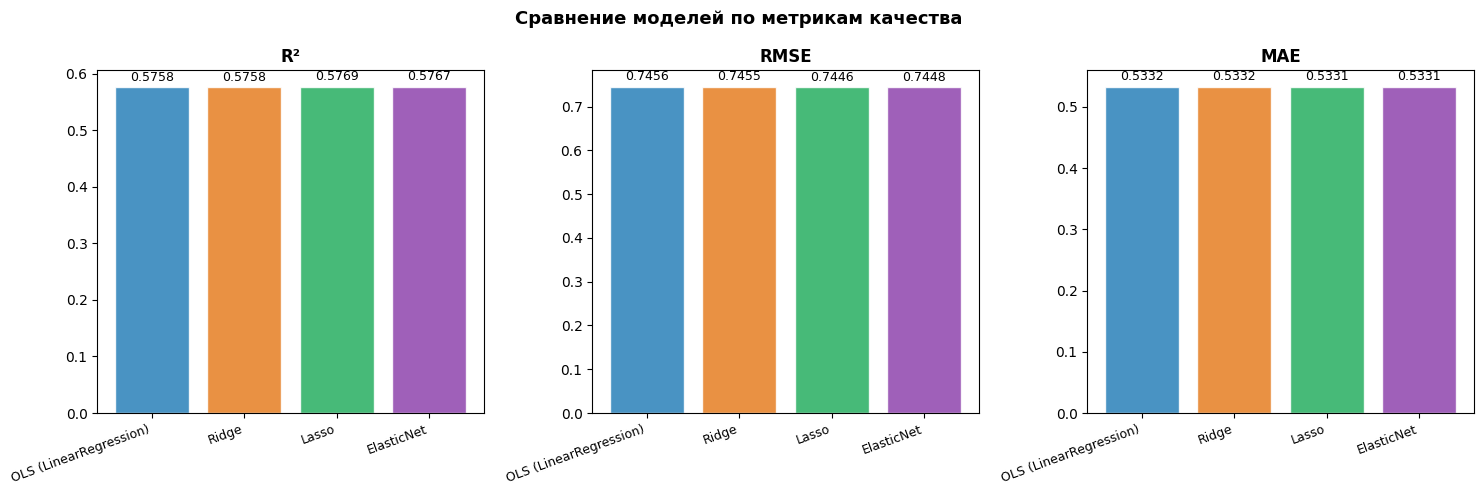

In [47]:
model_names = list(models_results.keys())
r2_vals   = [r2_score(y_test, p) for p, _ in models_results.values()]
rmse_vals = [np.sqrt(mean_squared_error(y_test, p)) for p, _ in models_results.values()]
mae_vals  = [mean_absolute_error(y_test, p) for p, _ in models_results.values()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Сравнение моделей по метрикам качества", fontsize=13, fontweight='bold')

bar_colors = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad']

for ax, vals, title, fmt in zip(
    axes,
    [r2_vals, rmse_vals, mae_vals],
    ["R²", "RMSE", "MAE"],
    ['.4f', '.4f', '.4f']
):
    bars = ax.bar(model_names, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:{fmt}}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("06_model_comparison.png", dpi=150, bbox_inches='tight')
ok("График сохранён: 06_model_comparison.png")
plt.show()

## Реализованные методы

- OLS — обычный МНК (Scikit-learn + Statsmodels)
- Ridge — L2-регуляризация
- Lasso — L1-регуляризация (отбор признаков)
- ElasticNet — комбинированная регуляризация
- 10-кратная кросс-валидация + GridSearchCV
- Диагностика мультиколлинеарности (VIF)
- Диагностика остатков + тест Шапиро-Уилка
- Визуализация: 6 графических блоков

## Выводы

1. **OLS** показал базовое качество (R² ≈ 0.60), но диагностика остатков выявила отклонение от нормальности (типично для больших выборок).

2. **VIF-анализ** обнаружил мультиколлинеарность (AveRooms/AveBedrms), что обосновывает применение регуляризации.

3. **Lasso** при оптимальном α = 0.001 не обнулил признаки, но коэффициенты Population и AveOccup оказались близки к нулю, что указывает на их невысокую значимость

4. **Ridge и ElasticNet** показали сопоставимое качество с OLS, но обеспечивают более стабильные коэффициенты.

5. **Рекомендуемая модель:** Lasso — оптимальный баланс между предсказательной способностью и интерпретируемостью.

## Созданные файлы

- `01_exploratory_analysis.png` — разведочный анализ
- `02_cross_validation.png` — кросс-валидация
- `03_regularization_paths.png` — кривые регуляризации
- `04_coef_comparison.png` — сравнение коэффициентов
- `05_residual_diagnostics.png` — диагностика остатков
- `06_model_comparison.png` — итоговое сравнение
